In [1]:
import os

input_dir = "C:\\Users\\HP\\PycharmProjects\\pythonProject\\images\\images"
target_dir = "C:\\Users\\HP\\PycharmProjects\\pythonProject\\annotations\\annotations\\trimaps"
input_img_paths = sorted(
    [os.path.join(input_dir, fname) for fname in os.listdir(input_dir) if fname.endswith(".jpg")]
)
target_paths = sorted(
    [os.path.join(target_dir, fname) for fname in os.listdir(target_dir) if fname.endswith(".png") and not fname.startswith(".")]
)

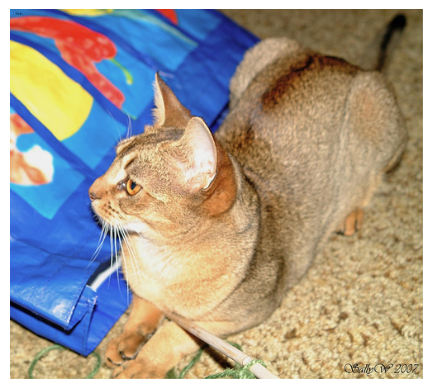

In [2]:
import matplotlib.pyplot as plt
from keras.utils import load_img, img_to_array
plt.axis("off")
plt.imshow(load_img(input_img_paths[9]))

In [3]:
def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    plt.axis("off")
    plt.imshow(normalized_array[:, :, 0], cmap="gray")

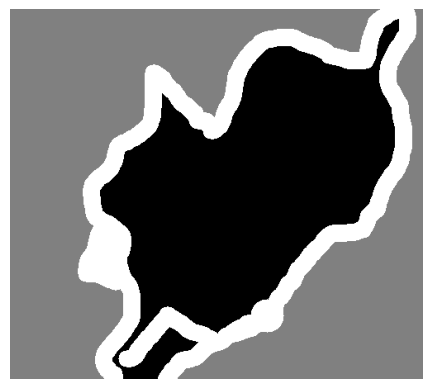

In [4]:
img = img_to_array(load_img(target_paths[9], color_mode="grayscale"))
display_target(img)

In [6]:
import numpy as np
import random

img_size = (200, 200)
num_imgs =  len(input_img_paths)

random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_paths)

def path_to_input_image(path):
    return img_to_array(load_img(path, target_size=img_size))   
def path_to_target(path):
    img = img_to_array(load_img(path, color_mode="grayscale", target_size=img_size))
    img = img.astype("uint8") - 1
    return img

input_imgs = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
target_imgs = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")
for i, (input_path, target_path) in enumerate(zip(input_img_paths, target_paths)):
    input_imgs[i] = path_to_input_image(input_path)
    target_imgs[i] = path_to_target(target_path)

num_val_samples = 1000
train_input_imgs = input_imgs[:-num_val_samples]
train_target = target_imgs[:-num_val_samples]
val_input_imgs = input_imgs[-num_val_samples:]
val_target = target_imgs[-num_val_samples:]

In [7]:
import keras
from keras import layers

def get_model(img_size, num_classes):
    inputs = keras.Input(shape=img_size + (3,))
    x = layers.Rescaling(1 / 255.0)(inputs)

    x = layers.Conv2D(64, 3, strides=2,activation="relu", padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    
    x = layers.Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)
    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)

    outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

    model = keras.Model(inputs, outputs)
    return model

model = get_model(img_size, num_classes=3)
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 200, 200, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 200, 200, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 100, 100, 64)      1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 100, 64)      36928     
                                                                 
 conv2d_2 (Conv2D)           (None, 50, 50, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 50, 50, 128)       147584    
                                                                 
 conv2d_4 (Conv2D)           (None, 25, 25, 256)       29516

In [8]:
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
callbacks = [
    keras.callbacks.ModelCheckpoint("modern_cnn.keras", save_best_only=True)
]   

history = model.fit(
    train_input_imgs, train_target, epochs=25, batch_size=32, validation_data=(val_input_imgs, val_target), callbacks=callbacks
)


Epoch 1/25


200/200 [==============================] - 1780s 9s/step - loss: 0.9385 - accuracy: 0.5793 - val_loss: 1.6751 - val_accuracy: 0.5896
Epoch 2/25
200/200 [==============================] - 642s 3s/step - loss: 0.8721 - accuracy: 0.5811 - val_loss: 0.8461 - val_accuracy: 0.5800
Epoch 3/25
200/200 [==============================] - 874s 4s/step - loss: 0.8232 - accuracy: 0.6252 - val_loss: 0.7626 - val_accuracy: 0.6769
Epoch 4/25
200/200 [==============================] - 615s 3s/step - loss: 0.7842 - accuracy: 0.6728 - val_loss: 0.7308 - val_accuracy: 0.6909
Epoch 5/25
200/200 [==============================] - 596s 3s/step - loss: 0.7485 - accuracy: 0.6887 - val_loss: 0.7022 - val_accuracy: 0.7083
Epoch 6/25
200/200 [==============================] - 5283s 27s/step - loss: 0.7160 - accuracy: 0.7010 - val_loss: 0.7605 - val_accuracy: 0.6876
Epoch 7/25
200/200 [==============================] - 1571s 8s/step - loss: 0.6884 - accuracy: 0.7147 - val_loss: 0.6559 - val_accuracy:

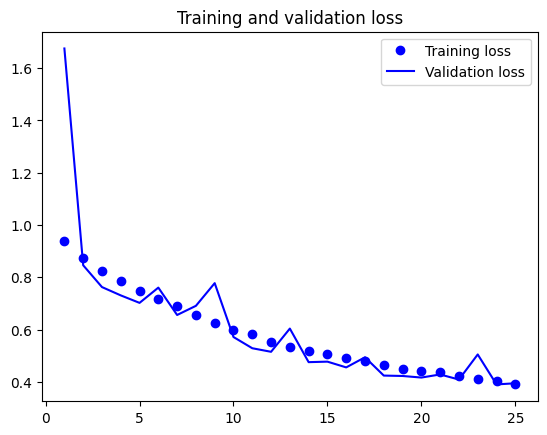

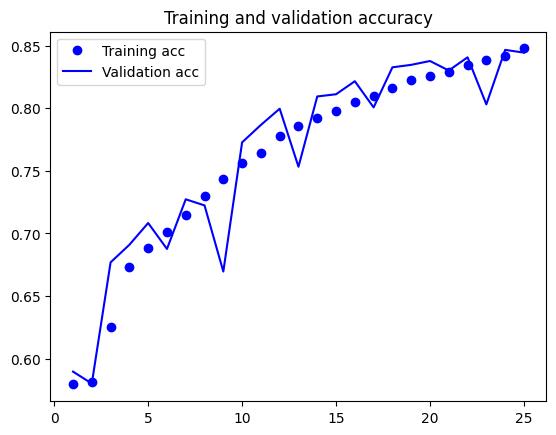

In [9]:
epochs = range(1, len(history.history["loss"]) + 1)
plt.plot(epochs, history.history["loss"], "bo", label="Training loss")
plt.plot(epochs, history.history["val_loss"], "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.figure()
plt.plot(epochs, history.history["accuracy"], "bo", label="Training acc")
plt.plot(epochs, history.history["val_accuracy"], "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

1/1 [==============================] - 0s 342ms/step


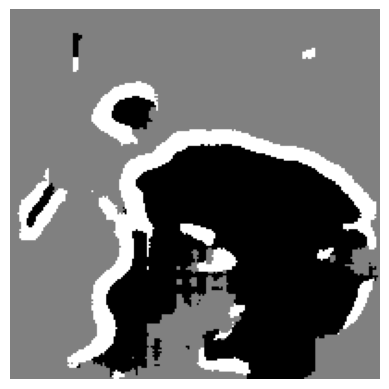

In [11]:
from keras.utils import array_to_img

model = keras.models.load_model("modern_cnn.keras")

i = 4
test_image = val_input_imgs[i]
plt.axis("off")
plt.imshow(array_to_img(test_image))

mask = model.predict(np.expand_dims(test_image, 0))[0]

def display_mask(mask):
    mask = np.argmax(mask, axis=-1)
    mask *= 127
    plt.axis("off")
    plt.imshow(mask, cmap="gray")

display_mask(mask)

classification，segmentation & test